<a href="https://colab.research.google.com/github/aishruban5566-ctrl/mlt-programs/blob/main/task%205.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounted at /content/drive

First 10 rows of the dataset:

    Class  Alcohol  Malic_acid   Ash  Alcalinity_of_ash  Magnesium  \
1     0.0    14.23        1.71  2.43               15.6      127.0   
2     0.0    13.20        1.78  2.14               11.2      100.0   
3     0.0    13.16        2.36  2.67               18.6      101.0   
4     0.0    14.37        1.95  2.50               16.8      113.0   
5     0.0    13.24        2.59  2.87               21.0      118.0   
6     0.0    14.20        1.76  2.45               15.2      112.0   
7     0.0    14.39        1.87  2.45               14.6       96.0   
8     0.0    14.06        2.15  2.61               17.6      121.0   
9     0.0    14.83        1.64  2.17               14.0       97.0   
10    0.0    13.86        1.35  2.27               16.0       98.0   

    Total_phenols  Flavanoids  Nonflavanoid_phenols  Proanthocyanins  \
1            2.80        3.06                  0.28             2.29   
2            2.65        2.

<Figure size 700x400 with 0 Axes>

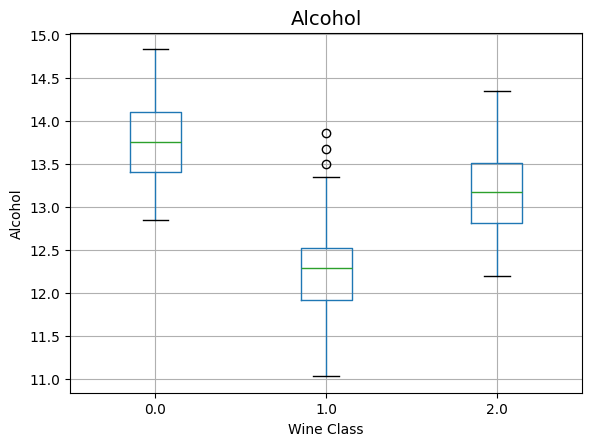

<Figure size 700x400 with 0 Axes>

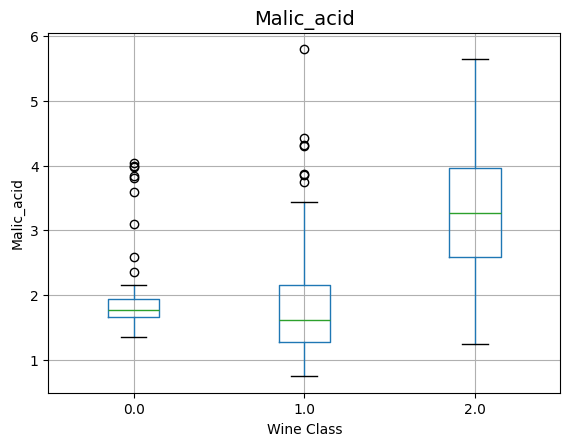

<Figure size 700x400 with 0 Axes>

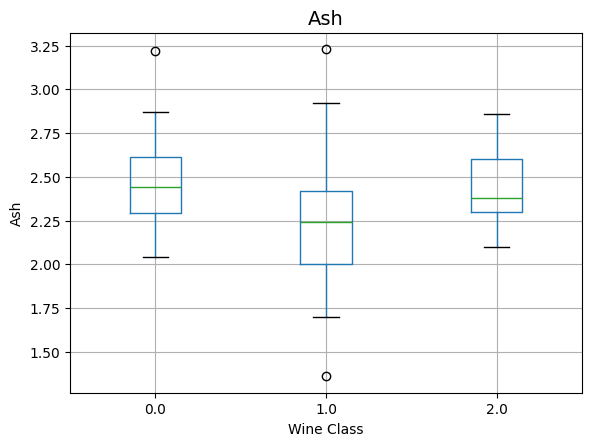

<Figure size 700x400 with 0 Axes>

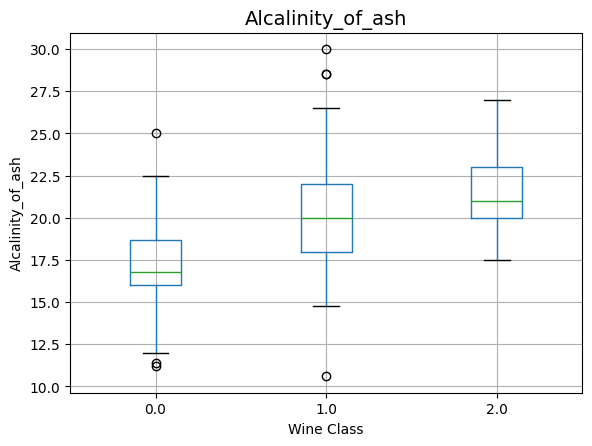

<Figure size 700x400 with 0 Axes>

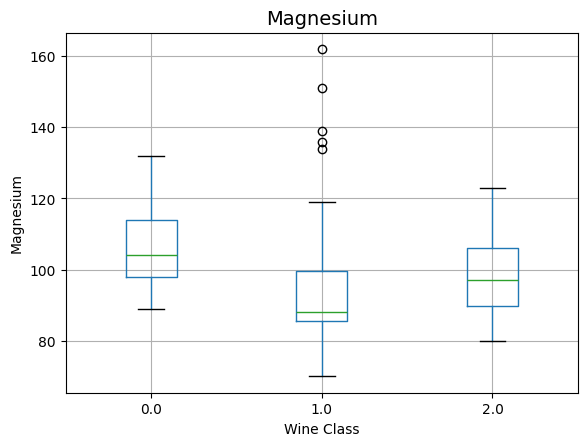

<Figure size 700x400 with 0 Axes>

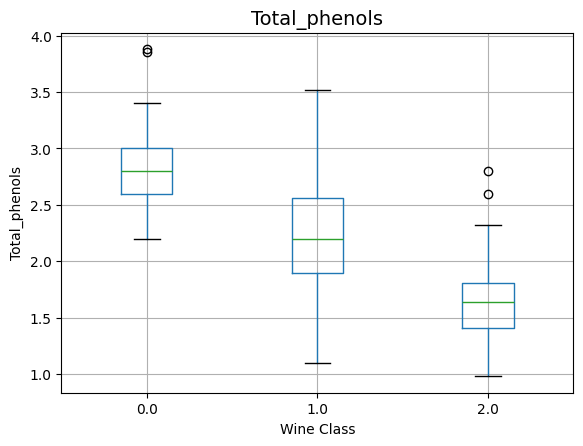

<Figure size 700x400 with 0 Axes>

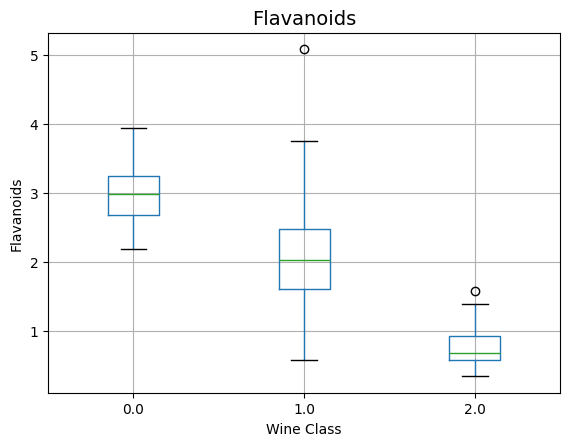

<Figure size 700x400 with 0 Axes>

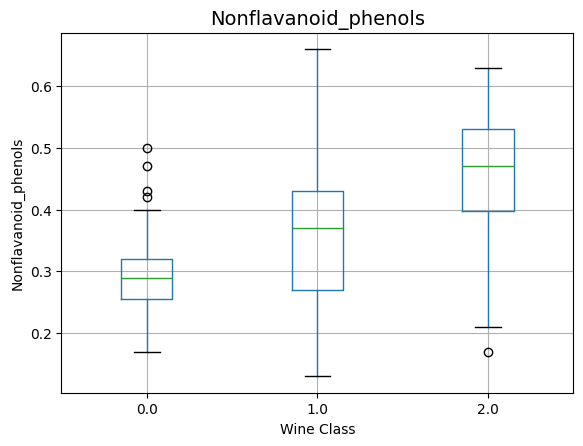

<Figure size 700x400 with 0 Axes>

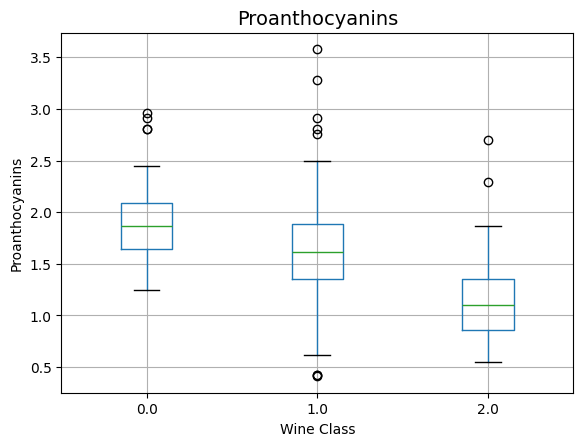

<Figure size 700x400 with 0 Axes>

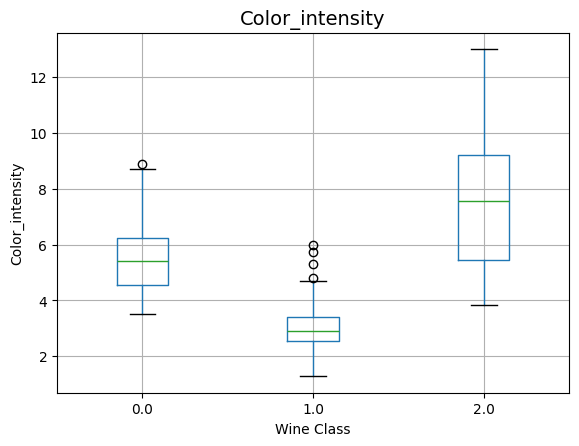

<Figure size 700x400 with 0 Axes>

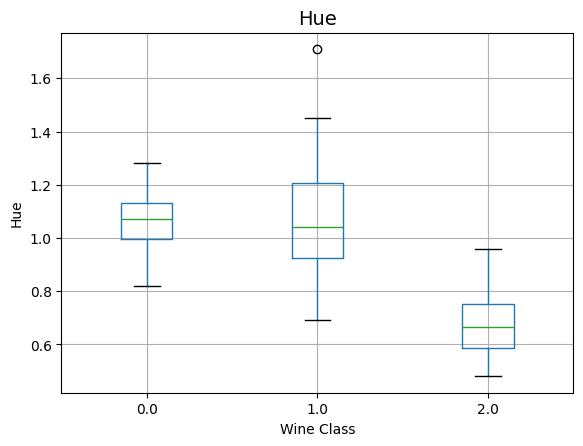

<Figure size 700x400 with 0 Axes>

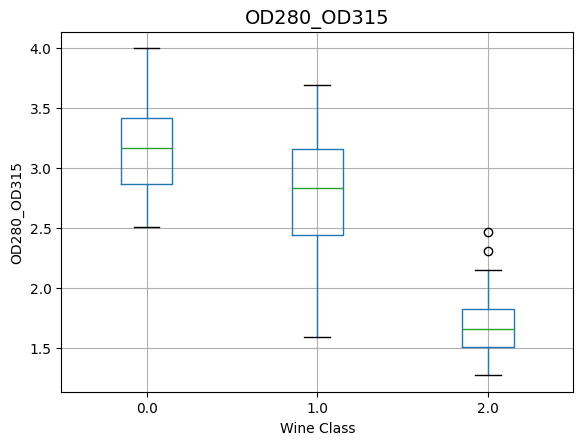

<Figure size 700x400 with 0 Axes>

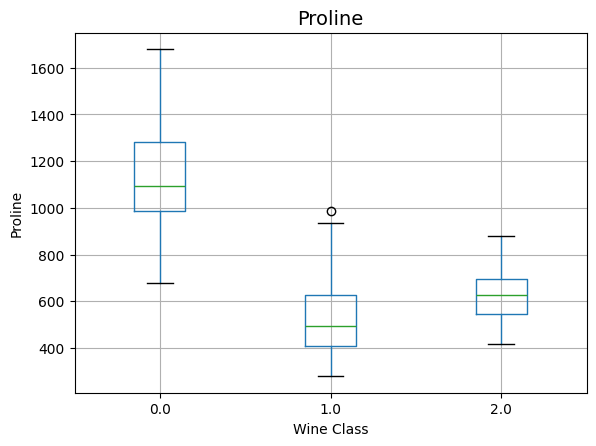

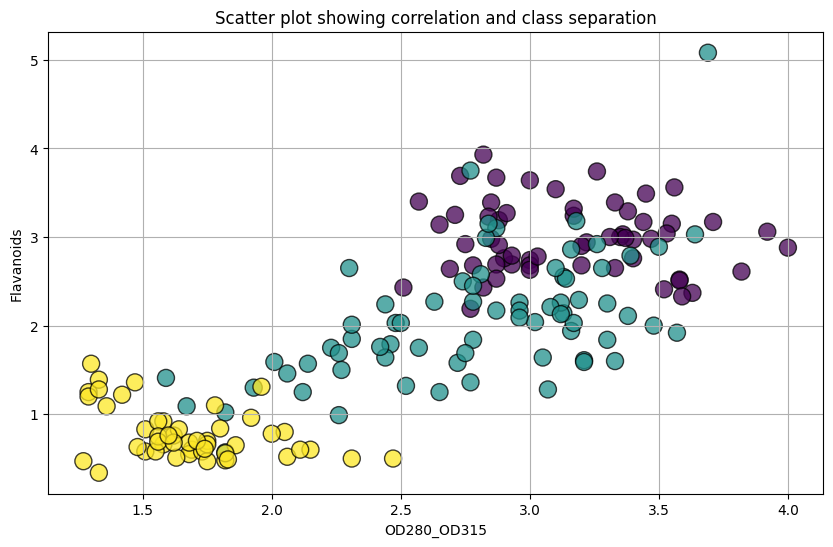

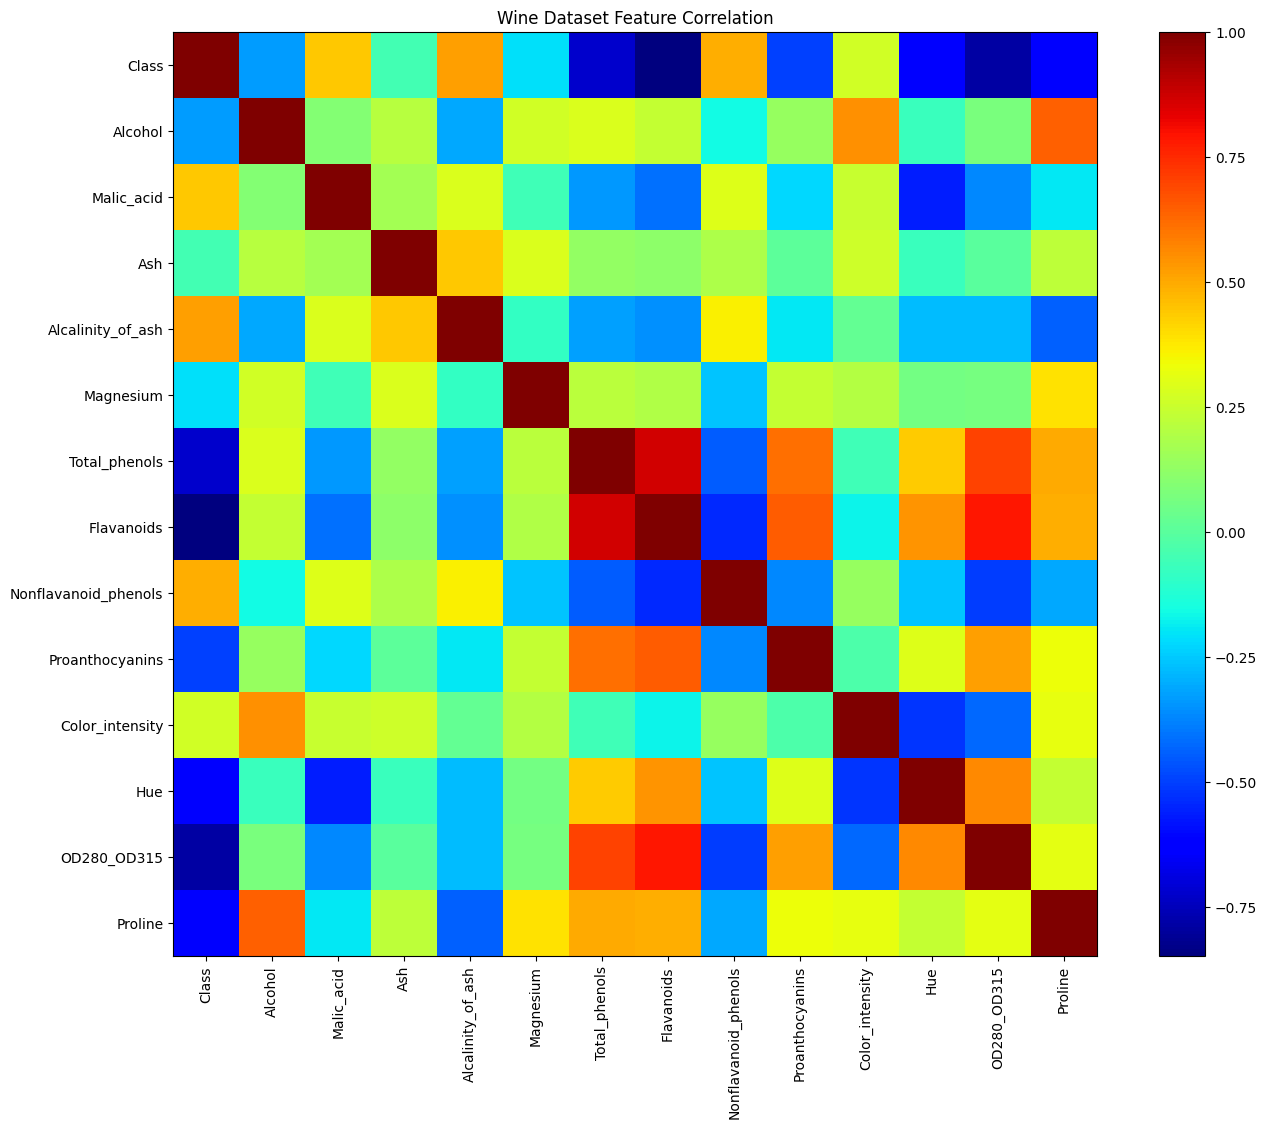


Standardized Data (first 10 rows):

    Alcohol  Malic_acid       Ash  Alcalinity_of_ash  Magnesium  \
0  1.518613   -0.562250  0.232053          -1.169593   1.913905   
1  0.246290   -0.499413 -0.827996          -2.490847   0.018145   
2  0.196879    0.021231  1.109334          -0.268738   0.088358   
3  1.691550   -0.346811  0.487926          -0.809251   0.930918   
4  0.295700    0.227694  1.840403           0.451946   1.281985   
5  1.481555   -0.517367  0.305159          -1.289707   0.860705   
6  1.716255   -0.418624  0.305159          -1.469878  -0.262708   
7  1.308617   -0.167278  0.890014          -0.569023   1.492625   
8  2.259772   -0.625086 -0.718336          -1.650049  -0.192495   
9  1.061565   -0.885409 -0.352802          -1.049479  -0.122282   

   Total_phenols  Flavanoids  Nonflavanoid_phenols  Proanthocyanins  \
0       0.808997    1.034819             -0.659563         1.224884   
1       0.568648    0.733629             -0.820719        -0.544721   
2       0.80

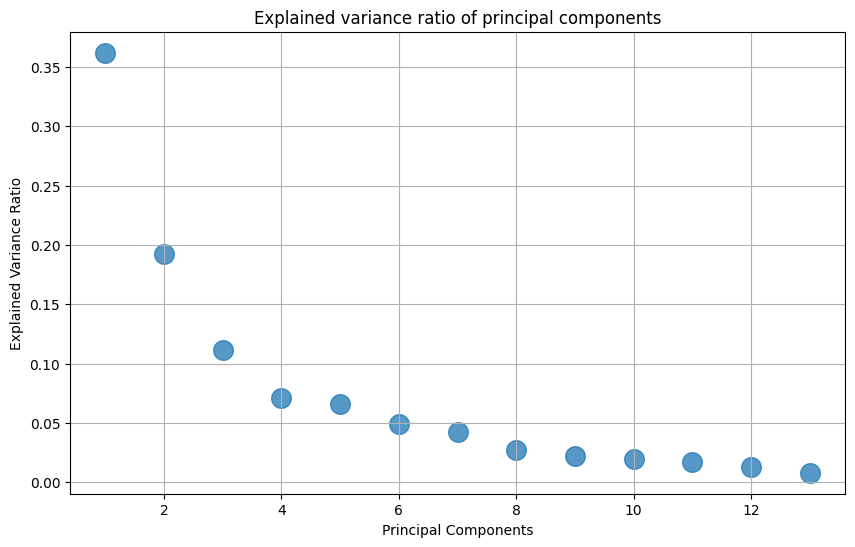

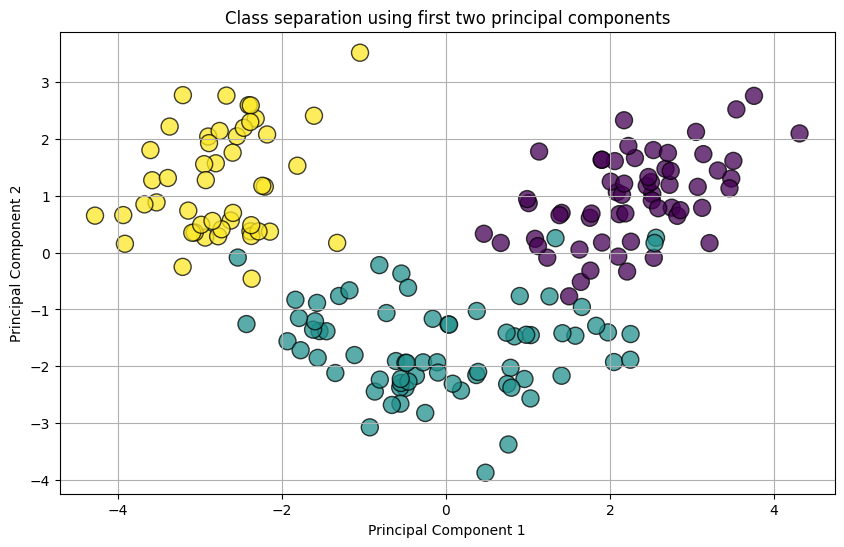

In [1]:
# -------------------------------
# Mount Google Drive
# -------------------------------
from google.colab import drive
drive.mount('/content/drive')

# -------------------------------
# Import Libraries
# -------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# -------------------------------
# Column names for Wine dataset
# -------------------------------
columns = [
    'Class','Alcohol','Malic_acid','Ash','Alcalinity_of_ash','Magnesium',
    'Total_phenols','Flavanoids','Nonflavanoid_phenols','Proanthocyanins',
    'Color_intensity','Hue','OD280_OD315','Proline'
]

# -------------------------------
# Load Dataset
# -------------------------------
df = pd.read_csv('/content/drive/MyDrive/wine.data.csv', header=None, names=columns)

# Convert to numeric values
df = df.apply(pd.to_numeric, errors='coerce')

# Remove missing values
df = df.dropna()

print("\nFirst 10 rows of the dataset:\n")
print(df.head(10))

print("\nSummary statistics:\n")
print(df.iloc[:,1:].describe())

# -------------------------------
# Boxplots
# -------------------------------
for c in df.columns[1:]:
    plt.figure(figsize=(7,4))
    df.boxplot(column=c, by='Class')
    plt.title(c, fontsize=14)
    plt.xlabel("Wine Class")
    plt.ylabel(c)
    plt.suptitle("")
    plt.show()

# -------------------------------
# Scatter Plot
# -------------------------------
plt.figure(figsize=(10,6))

plt.scatter(df['OD280_OD315'],
            df['Flavanoids'],
            c=df['Class'],
            edgecolors='k',
            alpha=0.75,
            s=150)

plt.grid(True)
plt.title("Scatter plot showing correlation and class separation")
plt.xlabel("OD280_OD315")
plt.ylabel("Flavanoids")
plt.show()

# -------------------------------
# Correlation Matrix
# -------------------------------
def correlation_matrix(data):
    fig, ax = plt.subplots(figsize=(16,12))
    cax = ax.imshow(data.corr(), cmap='jet', interpolation='nearest')

    plt.title("Wine Dataset Feature Correlation")
    plt.xticks(range(len(data.columns)), data.columns, rotation=90)
    plt.yticks(range(len(data.columns)), data.columns)

    fig.colorbar(cax)
    plt.grid(False)
    plt.show()

correlation_matrix(df)

# -------------------------------
# Standardization
# -------------------------------
scaler = StandardScaler()

X = df.drop('Class', axis=1)
y = df['Class']

X_scaled = scaler.fit_transform(X)

dfx = pd.DataFrame(X_scaled, columns=df.columns[1:])

print("\nStandardized Data (first 10 rows):\n")
print(dfx.head(10))

# -------------------------------
# PCA
# -------------------------------
pca = PCA(n_components=None)

pca.fit(dfx)

# Explained Variance Ratio Plot
plt.figure(figsize=(10,6))

plt.scatter(range(1, len(pca.explained_variance_ratio_) + 1),
            pca.explained_variance_ratio_,
            s=200,
            alpha=0.75)

plt.grid(True)
plt.title("Explained variance ratio of principal components")
plt.xlabel("Principal Components")
plt.ylabel("Explained Variance Ratio")
plt.show()

# -------------------------------
# Transform Data using PCA
# -------------------------------
dfx_trans = pd.DataFrame(pca.transform(dfx))

# -------------------------------
# PCA Scatter Plot
# -------------------------------
plt.figure(figsize=(10,6))

plt.scatter(dfx_trans[0],
            dfx_trans[1],
            c=y,
            edgecolors='k',
            alpha=0.75,
            s=150)

plt.grid(True)
plt.title("Class separation using first two principal components")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd

# Load the data — use header=None if there's no header in your CSV
data = pd.read_csv('/content/drive/MyDrive/find1.csv')  # Or add header=None if needed

concepts = np.array(data.iloc[:, :-1])
target = np.array(data.iloc[:, -1])

def learn(concepts, target):
    specific_h = concepts[0].copy()
    general_h = [["?" for _ in range(len(specific_h))] for _ in range(len(specific_h))]

    print("Initial Specific Hypothesis:\n", specific_h)
    print("Initial General Hypothesis:\n", general_h)

    for i, h in enumerate(concepts):
        if target[i].lower() == "yes":
            for x in range(len(specific_h)):
                if h[x] != specific_h[x]:
                    specific_h[x] = '?'
                    general_h[x][x] = '?'
        elif target[i].lower() == "no":
            for x in range(len(specific_h)):
                if h[x] != specific_h[x]:
                    general_h[x][x] = specific_h[x]
                else:
                    general_h[x][x] = '?'

        print(f"\nStep {i+1}:")
        print("Specific_h:\n", specific_h)
        print("General_h:\n", general_h)

    general_h = [g for g in general_h if g != ['?' for _ in range(len(specific_h))]]
    return specific_h, general_h

# Run learning function and print final results
s_final, g_final = learn(concepts, target)
print("\nFinal Specific Hypothesis:\n", s_final)
print("Final General Hypothesis:\n", g_final)

Mounted at /content/drive


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/find1.csv'